### Scenario 2: Modified Montúfar Example with Unequal Hyperrectangles

In this example, we compare the different sampling methods on a grid of unequally sized hyperrectangles. To do this, we modify the Montúfar (2014) example, where the linear regions form a grid of hypercubes, by changing the biases so that the regions have unequal sizes.

#### Imports:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
import scipy.stats.qmc as qmc
from pathlib import Path
from itertools import groupby

#### Functions to generate/load point sets:

In [3]:
def iid_uniform_sample(num_points,dimensions,runs,lower_bounds, upper_bounds, seed):
    """Generates several iid uniform sample of points in a space of some dimension
    Args:
        num_points: the number of points to sample
        dimensions: the dimension of the space to sample from
        runs: the number of independent samples to generate - corresponds to number of runs in an experiment
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        seed: a seed for reproducibility
    Returns:
        points: 3D array of shape (runs,num_points,dimensions) representing all the points across all the samples
    """

    rng = np.random.default_rng(seed)
    
    # Generate points in [0,1)^d
    points = rng.uniform(size=(runs,num_points,dimensions))
    
    # Map points to desired rectangular region
    points = lower_bounds + (upper_bounds - lower_bounds)*points

    # Map to torch tensor
    points = torch.tensor(points)
    
    return points

In [4]:
def halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed):
    """Generates several halton samples of points in a space of some dimension
    Args:
        num_points: the number of points to sample
        dimensions: the dimension of the space to sample from
        runs: the number of independent samples to generate - corresponds to number of runs in an experiment
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        seed: a seed for reproducibility
    Returns:
        points: 3D array of shape (runs, num_points, dimensions)
    """

    points = np.empty((runs,num_points,dimensions))
    
    # You can use the same rng for all the runs because the state will evolve every time you call qmc.Halton() again
    rng = np.random.default_rng(seed)
    for i in range(runs):
        sampler = qmc.Halton(d=dimensions,scramble=True,seed=rng)
        points[i,:,:] = sampler.random(num_points)

    points = points*(upper_bounds - lower_bounds) + lower_bounds

    # Convert to torch tensor for neural network processing
    points = torch.tensor(points)
    
    return points

In [5]:
def sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds):
    """Generates several sobol samples of points with different sample sizes
    Args:
        sample_sizes: a list of sample sizes to use for the region counting
        dimensions: the dimension of the space to sample from
        runs: the number of independent samples to generate - corresponds to number of runs in an experiment
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        seed: a seed for reproducibility
    Returns:
        all_points: a list of 3D arrays of shape (runs, num_points, dimensions)
    """

    all_points = []

    for i in range(len(sample_sizes)):
        
        points = np.empty((runs,sample_sizes[i],dimensions))
        rng = np.random.default_rng(seed=i)
        
        for j in range(runs):
            
            sampler = qmc.Sobol(d=dimensions,scramble=True,seed=rng)
            points[j,:,:] = sampler.random(sample_sizes[i])

        points = points*(upper_bounds - lower_bounds) + lower_bounds

        # Convert to torch tensor so we can put through the neural network
        points = torch.tensor(points)
        
        all_points.append(points)

    return all_points

In [6]:
def load_blue_noise_points(path, lower_bound, upper_bound):
    """Formats the blue noise point sets in a way that they can be used for the experiments
    Args:
        path: location where the blue noise point sets are stored
        lower_bounds: lower bound for all dimensions to adjust blue noise point sets from [0,1]^d
        upper_bounds: upper bound for all dimensions to adjust blue noise point sets from [0,1]^d
    Returns:
        blue_noise_sets: a list of lists containing the blue noise points for each dimension
                         and sample size within that dimension
    """

    dir_path = Path(path)

    def get_metadata(path_obj):
        parts = path_obj.stem.split('_')
        return int(parts[3]),int(parts[2])

    sorted_file_paths = sorted(dir_path.glob('*.npy'),key=get_metadata)

    blue_noise_sets = []

    for dimension, group in groupby(sorted_file_paths, key = lambda p: get_metadata(p)[0]):
        lower_bounds = np.full(dimension,lower_bound)
        upper_bounds = np.full(dimension,upper_bound)
        sublist_data = []
        for file_path in group:
            point_set = lower_bounds + np.load(str(file_path),mmap_mode="r")*(upper_bounds-lower_bounds)
            point_set = torch.tensor(point_set)
            sublist_data.append(point_set)
        blue_noise_sets.append(sublist_data)

    return blue_noise_sets

In [7]:
def grid_sample(sample_sizes, dimensions, lower_bound, upper_bound):
    """Generates a sample of n=m^d points in a regular lattice
    Args:
        sample sizes: a list of values of m (the number of points on each axis to construct the grid)
        dimensions: d (the number of dimensions of the input space)
        lower_bound: the lower bound of the input space in each dimension
        upper_bound: the upper bound of the input space in each dimension
    Returns:
        grid_sample: the grid of points
    """

    samples = []

    for points_per_axis in sample_sizes:

        # Exclude the endpoint along each axis because we are looking at the number of regions in [0,1)^d with 1 excluded
        coordinate_arrays = [np.linspace(lower_bound,upper_bound,int(points_per_axis)) for i in range(dimensions)]
        meshes = np.meshgrid(*coordinate_arrays,indexing="ij")
        grid_sample = np.column_stack([m.ravel() for m in meshes])
        grid_sample = torch.tensor(grid_sample)
        grid_sample = torch.unsqueeze(grid_sample,dim=0)

        samples.append(grid_sample)

    return samples

Test function for uniform sample:

In [29]:
num_points = 10000
dimensions = 2
runs=100
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
seed=1
points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed=1)

In [30]:
print(points.shape)

torch.Size([100, 10000, 2])


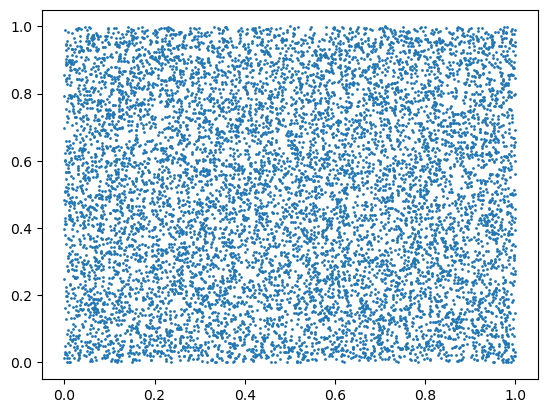

In [32]:
plt.scatter(points[0,:,0],points[0,:,1],s=1)

Test function for Halton sample:

In [78]:
num_points = 10000
dimensions = 2
runs=100
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
seed=1
points = halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed=1)

In [79]:
print(points.shape)

torch.Size([100, 10000, 2])


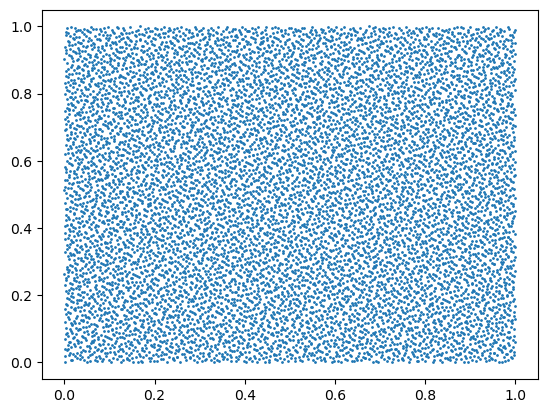

In [84]:
plt.scatter(points[0,:,0],points[0,:,1],s=1)

Test function for Sobol sample:

In [285]:
sample_sizes = [2**6,2**7,2**8,2**9]
dimensions = 2
runs=100
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
points = sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds)

In [295]:
first_set = points[3]

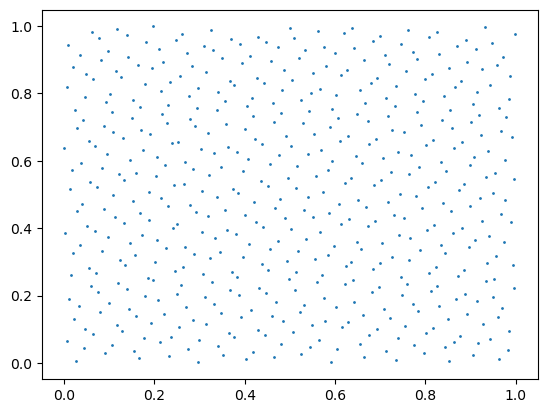

In [296]:
plt.scatter(first_set[5,:,0],first_set[5,:,1],s=1)

Test function to load blue noise point sets:

In [479]:
path = '/Users/gautamchauhan/Desktop/MSc Project Code/blue_noise_points_100_runs'
lower_bound = -1
upper_bound = 1
blue_noise_sets = load_blue_noise_points(path,lower_bound,upper_bound)

In [480]:
print(len(blue_noise_sets))

9


In [481]:
print(len(blue_noise_sets[0]))

10


In [514]:
blue_noise_2 = blue_noise_sets[0][4]

In [515]:
blue_noise_2.shape

torch.Size([100, 1024, 2])

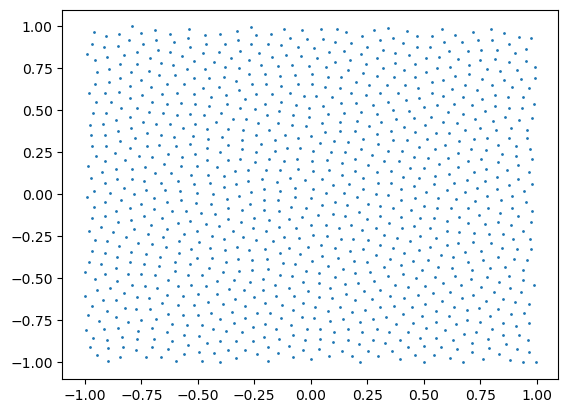

In [518]:
plt.scatter(blue_noise_2[1,:,0],blue_noise_2[1,:,1],s=1)

In [519]:
del blue_noise_sets

Test function to generate grid:

In [739]:
sample_sizes = [1,2,3,4,5]
dimensions = 4
lower_bound = -1
upper_bound = 1-1e-10

grid_samples = grid_sample(sample_sizes, dimensions, lower_bound, upper_bound)

In [740]:
grid = grid_samples[4]

In [741]:
print(grid.shape)

torch.Size([1, 625, 4])


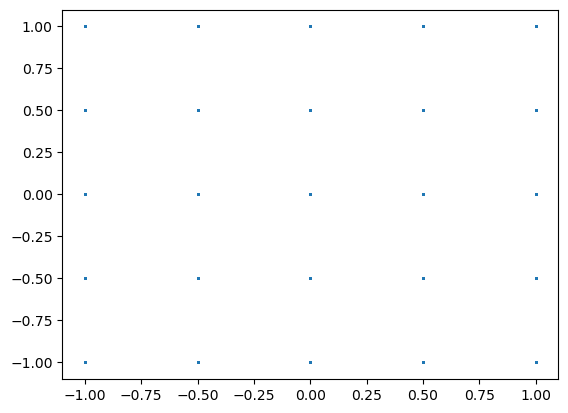

In [742]:
plt.scatter(grid[:,:,0],grid[:,:,1],s=1)

#### Code to set up MLP

In [12]:
class MLP(torch.nn.Module):
    def __init__(self,dimensions,neurons_per_hidden,custom_weights=None,custom_biases=None):
        """Set up the neural network model according to the specification given by parameters
        Args:
            dimensions: number of input dimensions
            neurons_per_hidden: 1D array or list containing widths of each layer
            custom_weights: None if Kaiming normal initialisation is to be used, otherwise a list of 2D torch tensors,
                            representing weight matrices to be used between each adjacent pair of layers
            custom_biases: None if Kaiming normal initialisation is to be used, otherwise a list of 1D torch tensors,
                            representing the bias of each neuron in each layer of the neural network
        """
        super().__init__()

        # Create a PyTorch list to store the layers and store the number of neurons per layer
        self.layers = torch.nn.ModuleList()
        self.architecture = neurons_per_hidden

        # Create first hidden layer using dimensions parameter
        hidden1 = torch.nn.Linear(dimensions, neurons_per_hidden[0], bias=True)
        self.layers.append(hidden1)
        self.layers.append(torch.nn.ReLU())
        
        # Create the remaining hidden layers
        for i in range(len(neurons_per_hidden)-1):
            hidden = torch.nn.Linear(neurons_per_hidden[i], neurons_per_hidden[i+1], bias=True)
            self.layers.append(hidden)
            self.layers.append(torch.nn.ReLU())

        # Set initial weights for all layers using user-input or Kaiming normal initialisation
        if custom_weights:
            with torch.no_grad():
                for i in range(len(self.layers)):
                    if isinstance(self.layers[i],torch.nn.Linear):
                        self.layers[i].weight.copy_(custom_weights[int(i/2)])
                        self.layers[i].bias.copy_(custom_biases[int(i/2)])
        else:
            generator = torch.Generator()
            generator.manual_seed(1)
            self.apply(lambda m: self.init_weights(m,generator))

    def init_weights(self, module, generator):
        """Initialise weights according to Kaiming normal distribution and biases according to a uniform distribution
        Args:
            module: the layer to be initialised
            generator: sets a random seed to ensure reproducibility of initial weights
        """
        if isinstance(module, torch.nn.Linear):
            torch.nn.init.kaiming_normal_(module.weight, nonlinearity="relu",generator=generator)
            torch.nn.init.uniform_(module.bias,a=-1.0,b=1,generator=generator)

    
    def forward(self,x):
        """Forward pass through the network to get the activations of each layer for a batch of data
        Args:
            x: a batch of inputs - 3D array of inputs of shape (number of runs, number of points, input dimension)
        Returns:
            activations: the activations of each neuron in each layer of the network,
                         as a 3D array of shape: (number of runs, number of points, total number of neurons)
        """
        x = x.float()
        for layer in self.layers:
            x = layer(x)
            # The layers are Linear, ReLU, Linear, ReLU, etc. Store activations after ReLU layers (>0 if on, =0 if off)
            if isinstance(layer,torch.nn.ReLU):
                # If we do not have the first layer, concatenate the activations along the last axis
                try:
                    activations = torch.cat((activations,x),axis=-1)
                # If we have the first layer, initialise the activations array
                except:
                    activations = x
        return activations

#### Code to count linear regions

Online region counting function which uses subsets of a larger sample (for Binomial Point Process/Halton Sequence):

In [8]:
def region_count_online(input_points,model,return_samples=False):
    """Count the number of unique linear regions in the input space of a MLP using a set of points distributed across the input space
    Args:
        points: torch tensor of points with shape (number of runs, number of points, dimensions)
        model: the neural network model we are analysing
        return_samples: Boolean flag telling you whether or not to return the samples corresponding with each region
    Returns:
        unique_counts: the number of regions counted using the sample points
        samples_by_region: a dictionary containing each unique region and the samples corresponding to it (or empty if return_samples=False)
    """

    # Set torch tensor for the number of regions counted in each run
    unique_counts = torch.zeros((input_points.shape[0],input_points.shape[1]))

    # Get array of activations with shape (number of runs, number of points, total number of neurons)
    activations = model(input_points)
    # For all the activations that are greater than 0, set the state to 1
    states = torch.zeros(activations.shape)
    states[activations>0] = 1
    states = states.to(torch.int64)
    
    # Get activation pattern by representing each series of activations as a base 2 number and converting to base 10
    cols = states.shape[-1]
    powers = 1 << torch.arange(cols - 1, -1, -1,dtype=torch.int64)
    activation_patterns = (states * powers).sum(dim=-1)

    # COUNT NUMBER OF UNIQUE REGIONS

    # Sort the activation patterns and get corresponding indices (stable = True ensures the first occurance is put first)
    sorted_t, indices = torch.sort(activation_patterns, dim=1, stable=True)
    
    # Find the first occurance of each new activation pattern as a Boolean Mask
    is_first_sorted = torch.ones_like(activation_patterns, dtype=torch.bool)
    is_first_sorted[:, 1:] = sorted_t[:, 1:] != sorted_t[:, :-1]
    
    # Put the true and false values back in their original order
    is_first_chronological = torch.empty_like(is_first_sorted)
    is_first_chronological.scatter_(dim=1, index=indices, src=is_first_sorted)
    
    # Count the number of true values up to each column using cumulative sum function in torch
    unique_counts = is_first_chronological.int().cumsum(dim=1)

    # GET ALL SAMPLES CORRESPONDING TO EACH REGION
    if return_samples:

        # Retrieve the unique patterns
        first_patterns = activation_patterns[0,:]
        unique_patterns = first_patterns[is_first_chronological[0,:]]
    
        samples_by_region = {}
        
        # Get the samples corresponding with each region
        for pattern in unique_patterns:
            input_points_first = input_points[0,:,:]
            samples_by_region[pattern] = input_points_first[activation_patterns[0,:]==pattern]

    else:

        samples_by_region = {}

    return unique_counts, samples_by_region

Offline region counting function which uses separate sample sizes (for Sobol Sequence/Gaussian Blue Noise)

In [9]:
def region_count_offline(input_points_list,model,return_samples=False):
    """Count the number of unique linear regions in the input space of a MLP using a set of points distributed across the input space
    Args:
        input_points_list: list of torch tensors of points with shape (number of runs, number of points, dimensions)
        model: the neural network model we are analysing
        return_samples: Boolean flag telling you whether or not to return the samples corresponding with each region
    Returns:
        unique_counts: the number of regions counted using the sample points
        samples_by_region: a dictionary containing each unique region and the samples corresponding to it (or empty if return_samples=False)
    """

    # Set torch tensor for the number of regions counted in each run
    runs = input_points_list[0].shape[0]
    unique_counts = torch.zeros((runs,len(input_points_list)))

    for i in range(len(input_points_list)):

        input_points = input_points_list[i]

        # Get array of activations with shape (number of runs, number of points, total number of neurons)
        activations = model(input_points)
        # For all the activations that are greater than 0, set the state to 1
        states = torch.zeros(activations.shape)
        states[activations>0] = 1
        states = states.to(torch.int64)
        
        # Get activation pattern by representing each series of activations as a base 2 number and converting to base 10
        cols = states.shape[-1]
        powers = 1 << torch.arange(cols - 1, -1, -1,dtype=torch.int64)
        activation_patterns = (states * powers).sum(dim=-1)
    
        # COUNT NUMBER OF UNIQUE REGIONS
    
        sorted_t, _ = torch.sort(activation_patterns, dim=1)
        changes = sorted_t[:, 1:] != sorted_t[:, :-1]
        counts_sample_size = changes.sum(dim=1) + 1

        unique_counts[:,i] = counts_sample_size

    # GET ALL SAMPLES CORRESPONDING TO EACH REGION
    if return_samples:

        # Retrieve the unique patterns
        unique_patterns = torch.unique(activation_patterns[0,:])
    
        samples_by_region = {}
        
        # Get the samples corresponding with each region
        for pattern in unique_patterns:
            input_points_final_samples = input_points_list[-1][0,:,:]
            samples_by_region[pattern] = input_points_final_samples[activation_patterns[0,:]==pattern]

    else:

        samples_by_region = {}

    return unique_counts, samples_by_region

#### Control Examples

**Simple Example Network from first presentation**

1. Uniform Samples

In [283]:
num_points = 10000
dimensions = 2
neurons_per_hidden = [2]
runs = 50
custom_weights = [torch.tensor([[1.0,-1.0],[1.0,1.0]])]
custom_biases = [torch.tensor([0.0,0.0])]
lower_bounds = np.full(dimensions,-1)
upper_bounds = np.full(dimensions,1)
seed = 1

model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)
unique_counts, samples_by_region = region_count_online(points,model,return_samples=True)

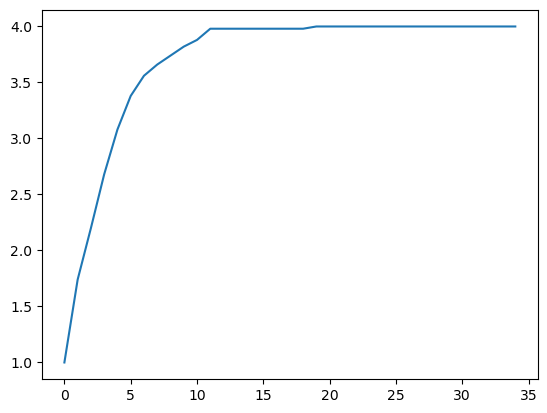

In [284]:
x = np.arange(35)
plt.plot(x,torch.mean(unique_counts.float(),axis=0)[:35])

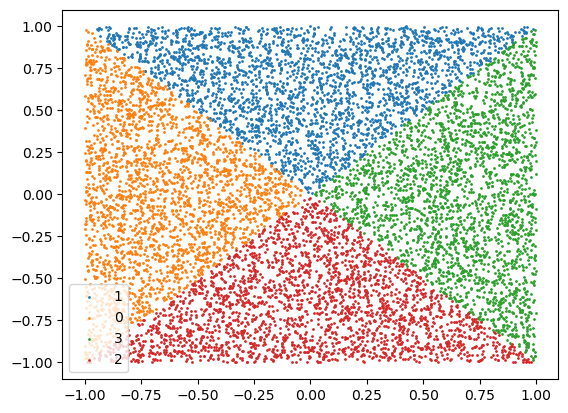

In [285]:
for key in samples_by_region.keys():
    samples = samples_by_region[key]
    plt.scatter(samples[:,0],samples[:,1],label=f"{key}",s=1)
plt.legend()

2. Halton Samples

In [291]:
num_points = 10000
dimensions = 2
neurons_per_hidden = [2]
runs = 50
custom_weights = [torch.tensor([[1.0,-1.0],[1.0,1.0]])]
custom_biases = [torch.tensor([0.0,0.0])]
lower_bounds = np.full(dimensions,-1)
upper_bounds = np.full(dimensions,1)
seed = 1

model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
points = halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)
unique_counts, samples_by_region = region_count_online(points,model,return_samples=True)

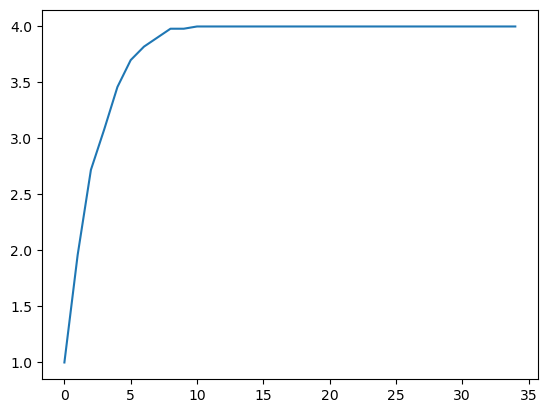

In [292]:
x = np.arange(35)
plt.plot(x,torch.mean(unique_counts.float(),axis=0)[:35])

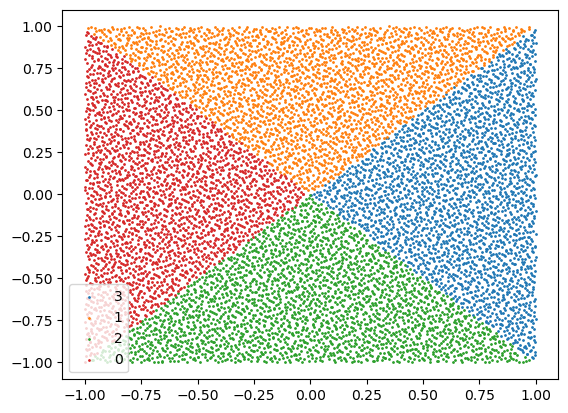

In [293]:
for key in samples_by_region.keys():
    samples = samples_by_region[key]
    plt.scatter(samples[:,0],samples[:,1],label=f"{key}",s=1)
plt.legend()

3. Sobol Samples

In [309]:
sample_sizes = [2**2,2**3,2**4,2**5,2**6,2**7,2**8,2**9,2**10,2**11,2**12,2**13]
dimensions = 2
neurons_per_hidden = [2]
runs = 50
custom_weights = [torch.tensor([[1.0,-1.0],[1.0,1.0]])]
custom_biases = [torch.tensor([0.0,0.0])]
lower_bounds = np.full(dimensions,-1)
upper_bounds = np.full(dimensions,1)
seed = 1

model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
points = sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds)
unique_counts, samples_by_region = region_count_offline(points,model,return_samples=True)

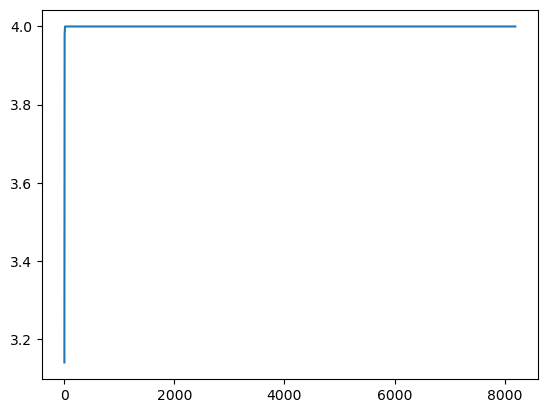

In [311]:
plt.plot(sample_sizes,torch.mean(unique_counts.float(),axis=0))

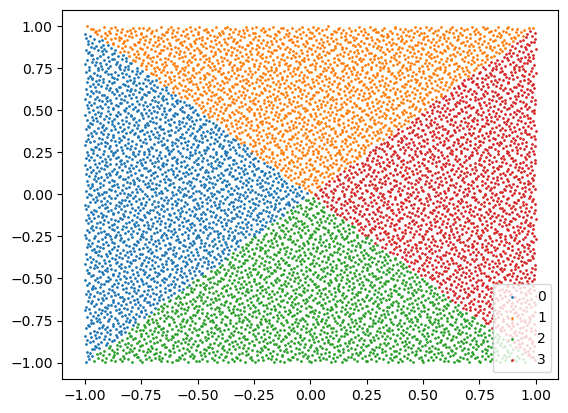

In [312]:
for key in samples_by_region.keys():
    samples = samples_by_region[key]
    plt.scatter(samples[:,0],samples[:,1],label=f"{key}",s=1)
plt.legend()

**Network from Bounding and Counting**

1. Uniform Samples

In [334]:
num_points = 50000
dimensions = 2
neurons_per_hidden = [2,2,2]
runs = 50
custom_weights = [torch.tensor([[-1.0,1.0],[1.0,1.0]]), torch.tensor([[-1.0,-3.0],[-3.0,-1.0]]),torch.tensor([[1.0,3.0],[3.0,1.0]])]
custom_biases = [torch.tensor([0.0,-4.0]),torch.tensor([4.0,4.0]),torch.tensor([-4.0,-4.0])]
lower_bounds = np.array([-0.5,-0.5])
upper_bounds = np.array([4.5,4.5])
seed = 1

model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)
unique_counts, samples_by_region = region_count_online(points,model,return_samples=True)

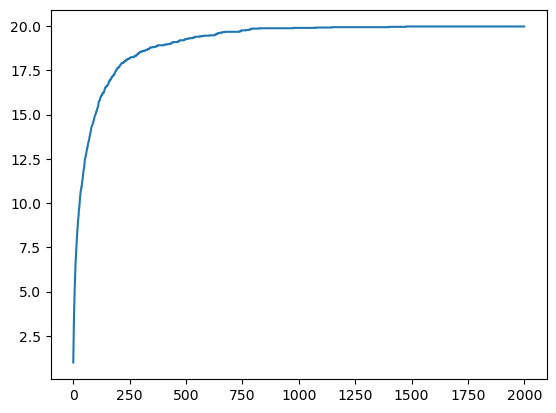

In [336]:
x = np.arange(2000)
plt.plot(x,torch.mean(unique_counts.float(),axis=0)[:2000])

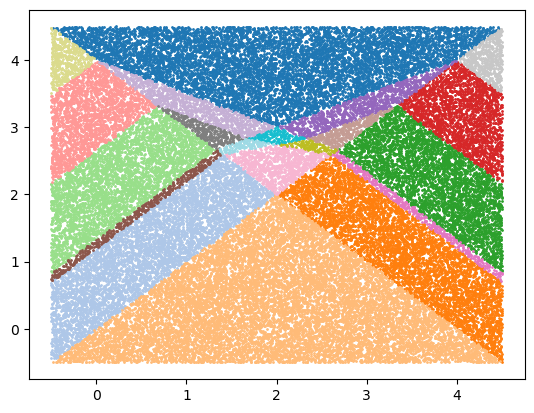

In [322]:
import matplotlib.pyplot as plt

cmap = plt.get_cmap('tab20') 

for i, (key, samples) in enumerate(samples_by_region.items()):
    color = cmap(i)
    plt.scatter(samples[:, 0], samples[:, 1], label=f"{key}", s=1, c=[color])

2. Halton Samples

In [337]:
num_points = 50000
dimensions = 2
neurons_per_hidden = [2,2,2]
runs = 50
custom_weights = [torch.tensor([[-1.0,1.0],[1.0,1.0]]), torch.tensor([[-1.0,-3.0],[-3.0,-1.0]]),torch.tensor([[1.0,3.0],[3.0,1.0]])]
custom_biases = [torch.tensor([0.0,-4.0]),torch.tensor([4.0,4.0]),torch.tensor([-4.0,-4.0])]
lower_bounds = np.array([-0.5,-0.5])
upper_bounds = np.array([4.5,4.5])
seed = 1

model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
points = halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)
unique_counts, samples_by_region = region_count_online(points,model,return_samples=True)

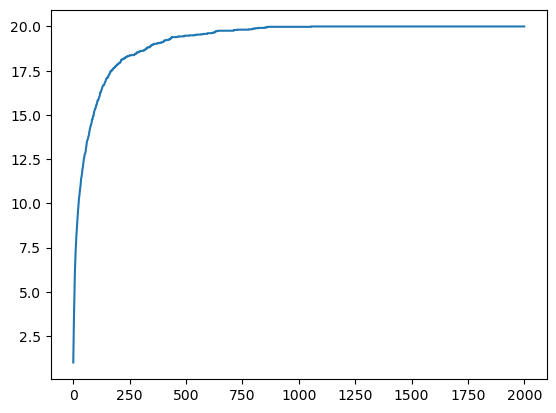

In [339]:
x = np.arange(2000)
plt.plot(x,torch.mean(unique_counts.float(),axis=0)[:2000])

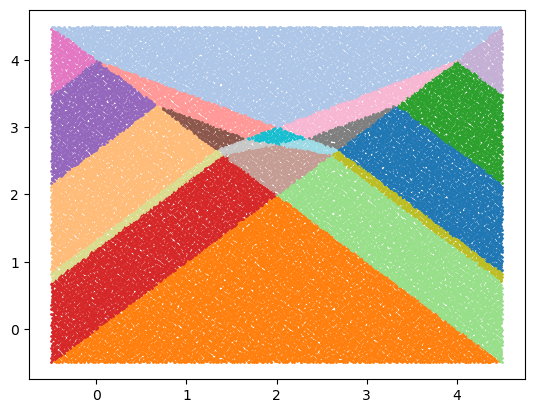

In [325]:
import matplotlib.pyplot as plt

cmap = plt.get_cmap('tab20') 

for i, (key, samples) in enumerate(samples_by_region.items()):
    color = cmap(i)
    plt.scatter(samples[:, 0], samples[:, 1], label=f"{key}", s=1, c=[color])

3. Sobol samples

In [340]:
sample_sizes = [2**2,2**3,2**4,2**5,2**6,2**7,2**8,2**9,2**10,2**11,2**12,2**13,2**14,2**15]
dimensions = 2
neurons_per_hidden = [2,2,2]
runs = 50
custom_weights = [torch.tensor([[-1.0,1.0],[1.0,1.0]]), torch.tensor([[-1.0,-3.0],[-3.0,-1.0]]),torch.tensor([[1.0,3.0],[3.0,1.0]])]
custom_biases = [torch.tensor([0.0,-4.0]),torch.tensor([4.0,4.0]),torch.tensor([-4.0,-4.0])]
lower_bounds = np.array([-0.5,-0.5])
upper_bounds = np.array([4.5,4.5])
seed = 1

model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
points = sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds)
unique_counts, samples_by_region = region_count_offline(points,model,return_samples=True)

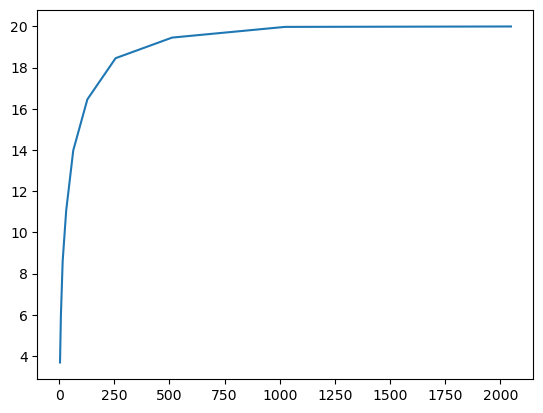

In [341]:
plt.plot(sample_sizes[:10],torch.mean(unique_counts.float(),axis=0)[:10])

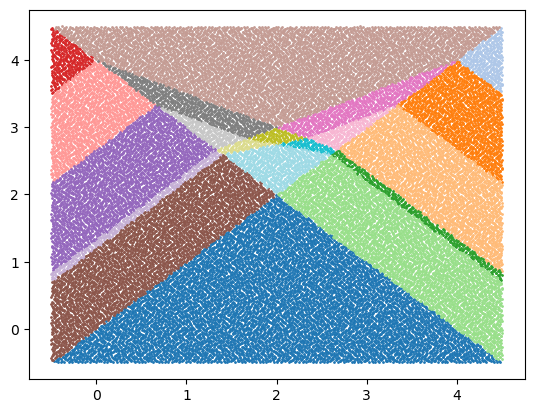

In [342]:
import matplotlib.pyplot as plt

cmap = plt.get_cmap('tab20') 

for i, (key, samples) in enumerate(samples_by_region.items()):
    color = cmap(i)
    plt.scatter(samples[:, 0], samples[:, 1], label=f"{key}", s=1, c=[color])

**RESULT**: all controls have passed

#### Formal Experiment Function

In [10]:
def experiment_3(sample_points,hidden_neurons,dimensions,runs=100,mode="online",return_samples=False):
    """Experiment for region counting using Montufar hypercubes example
    Args:
        sample_points: the sampling points used to count the regions - either numpy array (online counting) or list of arrays (offline)
        hidden_neurons: the number of neurons in the single hidden layer
        dimensions: the number of input dimensions
        runs: the number of times to rerun the experiment with different independent samples
        mode: whether to use the online/offline version of the region counting function
              online is used for BPP/Halton and offline for Sobol/Blue Noise
    Returns:
        unique_counts: 2D array of number of regions found after each number of samples for the different runs
    """

    p = int(np.floor(hidden_neurons/dimensions))
    
    # Set the network weights using p and dimension
    custom_weights = []
    for i in range(dimensions):
        segment_weights = [0 for i in range(dimensions)]
        segment_weights[i] = 1
        custom_weights += [segment_weights for _ in range(p)]
    custom_weights = [torch.tensor(custom_weights)]

    # Set the network biases so that we have a repeating pattern of small and large regions
    def generate_sequence(p):
        sequence = [0]
        for i in range(1,p):
            if i%2 == 1:
                # For every group of 2, make the first region 3 times bigger than the other in each axis
                value = -i/p - 1/(2*p)
            else:
                value = -i/p
            sequence.append(value)
        return sequence

    sequence = generate_sequence(p)
    custom_biases = [torch.tensor(np.tile(sequence, dimensions))]
        
    # custom_biases = [torch.tensor(np.tile([-np.sqrt(i)/p for i in range(p)], dimensions))]

    # Set up neural network - number of hidden neurons is p*n0 rather than hidden_neurons because the remainder neurons have weights
    # and biases set to 0 so they are essentially "dummy" neurons
    neurons_per_hidden = [p*dimensions]
    model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
    if mode == "online":
        unique_counts, samples_by_region = region_count_online(sample_points,model,return_samples=return_samples)
    else:
        unique_counts, samples_by_region = region_count_offline(sample_points,model,return_samples=return_samples)

    return unique_counts, samples_by_region

In [25]:
num_points = 1000000
all_dimensions = [2,3,4]
runs = 100
seed = 1
hidden_neurons = 24

iid_counts_experimental = np.empty((max(all_dimensions),runs,num_points))
all_samples_by_region = []

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region susing those point sets and assign to the appropriate part of iid_counts
    unique_counts,samples_by_region_experimental = experiment_3(sample_points,hidden_neurons,dimensions,runs,mode="online",return_samples=True)
    unique_counts = unique_counts.detach().numpy()
    iid_counts_experimental[dimensions-2,:,:] = unique_counts
    all_samples_by_region.append(samples_by_region_experimental)

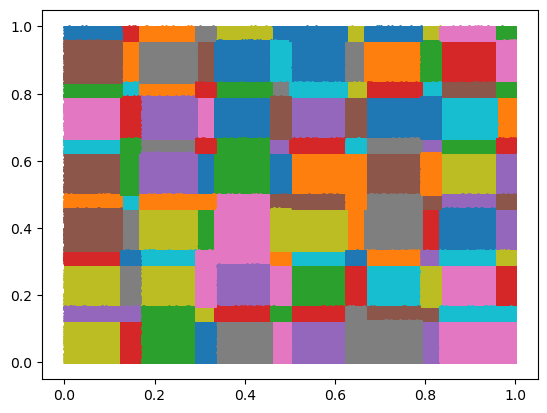

In [26]:
for key in all_samples_by_region[0]:
    plt.scatter(all_samples_by_region[0][key][:,0],all_samples_by_region[0][key][:,1],s=1)

In [27]:
print(iid_counts_experimental)

[[[1.000e+00 2.000e+00 3.000e+00 ... 1.440e+02 1.440e+02 1.440e+02]
  [1.000e+00 2.000e+00 3.000e+00 ... 1.440e+02 1.440e+02 1.440e+02]
  [1.000e+00 2.000e+00 3.000e+00 ... 1.440e+02 1.440e+02 1.440e+02]
  ...
  [1.000e+00 2.000e+00 3.000e+00 ... 1.440e+02 1.440e+02 1.440e+02]
  [1.000e+00 2.000e+00 3.000e+00 ... 1.440e+02 1.440e+02 1.440e+02]
  [1.000e+00 2.000e+00 3.000e+00 ... 1.440e+02 1.440e+02 1.440e+02]]

 [[1.000e+00 2.000e+00 3.000e+00 ... 5.120e+02 5.120e+02 5.120e+02]
  [1.000e+00 2.000e+00 3.000e+00 ... 5.120e+02 5.120e+02 5.120e+02]
  [1.000e+00 2.000e+00 3.000e+00 ... 5.120e+02 5.120e+02 5.120e+02]
  ...
  [1.000e+00 2.000e+00 3.000e+00 ... 5.120e+02 5.120e+02 5.120e+02]
  [1.000e+00 2.000e+00 3.000e+00 ... 5.120e+02 5.120e+02 5.120e+02]
  [1.000e+00 2.000e+00 3.000e+00 ... 5.120e+02 5.120e+02 5.120e+02]]

 [[1.000e+00 2.000e+00 3.000e+00 ... 1.296e+03 1.296e+03 1.296e+03]
  [1.000e+00 2.000e+00 3.000e+00 ... 1.296e+03 1.296e+03 1.296e+03]
  [1.000e+00 2.000e+00 3.000e+00

In [37]:
uniform_mean_experimental = np.mean(iid_counts_experimental[2],axis=0)

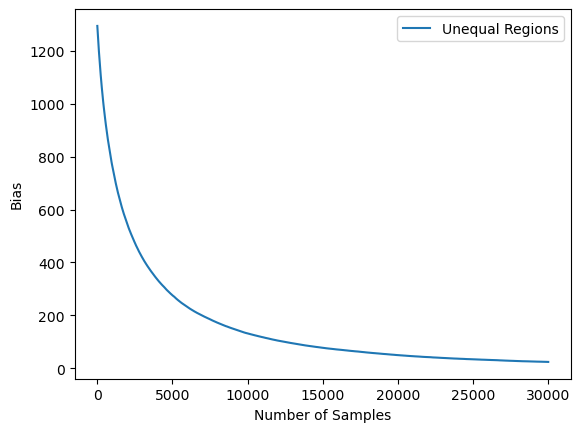

In [41]:
x = np.arange(30000)
plt.plot(x,1296-uniform_mean_experimental[:30000],label="Unequal Regions")
plt.xlabel("Number of Samples")
plt.ylabel("Bias")
plt.legend()

In [47]:
volume_fractions = []
for key in all_samples_by_region[2].keys():
    count = len(all_samples_by_region[2][key])
    volume_fractions.append(count/1000000)

(array([ 84., 320.,   1.,   0., 281., 205.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,  18., 229.,  77.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   1.,   7.,  30.,  35.,   8.]),
 array([3.3000e-05, 1.1380e-04, 1.9460e-04, 2.7540e-04, 3.5620e-04,
        4.3700e-04, 5.1780e-04, 5.9860e-04, 6.7940e-04, 7.6020e-04,
        8.4100e-04, 9.2180e-04, 1.0026e-03, 1.0834e-03, 1.1642e-03,
        1.2450e-03, 1.3258e-03, 1.4066e-03, 1.4874e-03, 1.5682e-03,
        1.6490e-03, 1.7298e-03, 1.8106e-03, 1.8914e-03, 1.9722e-03,
        2.0530e-03, 2.1338e-03, 2.2146e-03, 2.2954e-03, 2.3762e-03,
        2.4570e-03, 2.5378e-03, 2.6186e-03, 2.6994e-03, 2.7802e-03,
        2.8610e-03, 2.9418e-03, 3.0226e-03, 3.1034e-03, 3.1842e-03,
        3.2650e-03, 3.3458e-03, 3.4266e-03, 3.5074e-03, 3.5882e-03,
        3.6690e-03, 3.7498e-03, 3.8306e-03, 3.

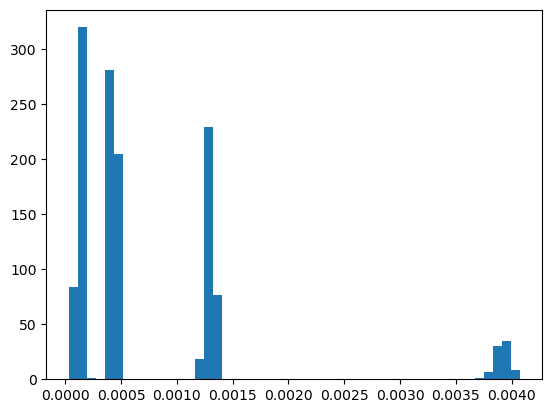

In [48]:
regions = np.arange(144)
plt.hist(volume_fractions,bins=50)

#### Experiment 2C

**EXPERIMENT 2C:**
- neurons per hidden $= 20$
- dimensions $= 2,3,4,5,6,7,8,9,10$
- regions $= 144, 512, 1296, 1024, 4096, 2187, 6561, 512, 1024$

1. Uniform Sampling Graphs

- Bias against number of samples
- Standard deviation against number of samples
- Maximum Variance against true number of regions

In [360]:
num_points = 50000
all_dimensions = [2,3,4,5,6,7,8,9,10]
runs = 100
seed = 1
hidden_neurons = 24

iid_counts_c = np.empty((max(all_dimensions),runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region susing those point sets and assign to the appropriate part of iid_counts
    unique_counts = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="online")
    unique_counts = unique_counts.detach().numpy()
    iid_counts_c[dimensions-2,:,:] = unique_counts

In [361]:
uniform_mean_c = np.mean(iid_counts_c,axis=1)
uniform_variances_c = np.var(iid_counts_c,axis=1)

In [362]:
x = np.arange(50000)

Text(0, 0.5, 'Bias($L_n$)')

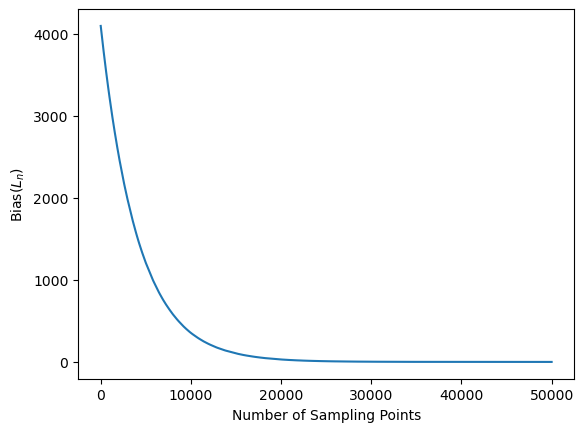

In [367]:
plt.plot(x,4096-uniform_mean_c[4])
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"Bias($L_n$)")

Text(0, 0.5, '$\\sigma(L_n)$')

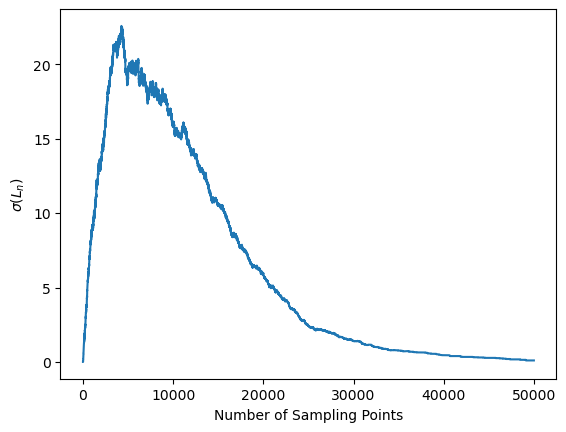

In [369]:
x = np.arange(50000)
plt.plot(x,np.sqrt(uniform_variances_c[4]))
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$\sigma(L_n)$")

In [370]:
maximum_uniform_variances_c = np.max(uniform_variances_c,axis=1)[:-1]

In [378]:
true_count = [np.floor(24/i)**i for i in range(2,11)]

In [379]:
coefs = np.polyfit(np.log(true_count),np.log(maximum_uniform_variances_c),deg=1)

In [380]:
m = coefs[0]
c = coefs[1]

In [381]:
print("Power: " + str(m))

Power: 1.0017433468977623


In [382]:
print("Multiplier: " + str(np.exp(c)))

Multiplier: 0.11185955566694404


In [408]:
print(c)

-2.1905111618212936


Text(0, 0.5, '$\\log(\\text{Maximum Variance})$')

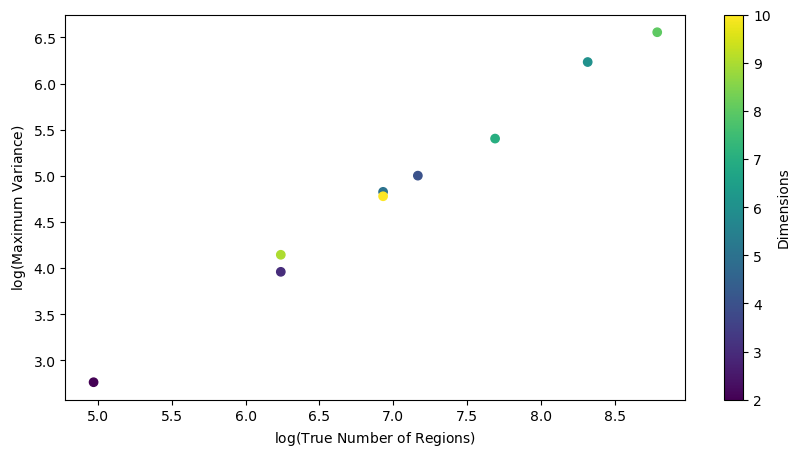

In [407]:
plt.figure(figsize=(10,5))
plt.scatter(np.log(true_count),np.log(maximum_uniform_variances_c),c=all_dimensions,cmap="viridis")
plt.colorbar(label="Dimensions")
plt.xlabel(r"$\log(\text{True Number of Regions})$")
plt.ylabel(r"$\log(\text{Maximum Variance})$")

So the simulation tells us that $\sigma^2_{\max} \approx 0.11 L$

Theory tells us that the maximum variance is given by:

$\sigma^2_{\text{max}} = L \frac{\lambda}{1+2 \lambda}$ with $e^{\lambda} = 1 + 2 \lambda$

Numerically solving to get a numerical value for $\lambda$ gives:

In [471]:
def f(x):
    return np.exp(x) - 1 - 2*x

In [472]:
x = scipy.optimize.fsolve(f,x0=1)

In [477]:
constant = x/(1+2*x)**2

In [478]:
print(constant)

[0.10181609]


Then we have $\sigma^2_{\max} \approx 0.10L$ which is roughly what we saw in our simulation

2. Uniform/Halton/Sobol/Blue Noise/Grid Comparison Graphs

- Difference in region count between method and uniform against sample size for dimensions 2,4,6,8
- Standard deviation against sample size for dimensions 2,4,6,8

HALTON:

In [384]:
num_points = 50000
all_dimensions = [2,3,4,5,6,7,8,9,10]
runs = 100
seed = 1
hidden_neurons = 24

halton_counts_c = np.empty((max(all_dimensions),runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region susing those point sets and assign to the appropriate part of iid_counts
    unique_counts = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="online")
    unique_counts = unique_counts.detach().numpy()
    halton_counts_c[dimensions-2,:,:] = unique_counts

SOBOL:

In [387]:
all_dimensions = [2,3,4,5,6,7,8,9,10]
sample_sizes = [2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]
runs = 100
hidden_neurons = 24

sobol_counts_c = np.empty((max(all_dimensions),runs,len(sample_sizes)))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds)

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    sobol_counts_c[dimensions-2,:,:] = unique_counts

BLUE NOISE:

In [621]:
hidden_neurons = 24
runs = 100
all_dimensions = [2,3,4,5,6,7,8,9,10]

# Load point sets and get them into the right format
path = '/Users/gautamchauhan/Desktop/MSc Project Code/blue_noise_points_100_runs'
lower_bound = 0
upper_bound = 1

blue_noise_sets = load_blue_noise_points(path,lower_bound,upper_bound)

blue_noise_counts_c = np.empty((max(all_dimensions),runs,len(blue_noise_sets[0])))

for dimensions in all_dimensions:

    # Pick out the sample points corresponding to the dimension
    sample_points = blue_noise_sets[dimensions-2]

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts, samples_by_region = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    blue_noise_counts_c[dimensions-2,:,:] = unique_counts

GRID:

In [751]:
hidden_neurons = 24
all_dimensions = [2,3,4,5,6,7,8,9,10]
# For each dimension, generate up to 50000 points in a regular grid 
points_per_axis = [np.arange(2,np.ceil(50000**(1/d))) for d in all_dimensions]
lower_bound = 1e-10
upper_bound = 1-1e-10

grid_counts_c = []

for dimensions in all_dimensions:

    # Pick out the sample points corresponding to the dimension
    sample_points = points_per_axis[dimensions-2]
    grid_points = grid_sample(sample_points,dimensions,lower_bound,upper_bound)

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts, samples_by_region = experiment_2(grid_points,hidden_neurons,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    grid_counts_c.append(unique_counts)

In [389]:
halton_mean_c = np.mean(halton_counts_c,axis=1)
halton_variances_c = np.var(halton_counts_c,axis=1)

In [390]:
sobol_mean_c = np.mean(sobol_counts_c,axis=1)
sobol_variances_c = np.var(sobol_counts_c,axis=1)

In [622]:
blue_noise_mean_c = np.mean(blue_noise_counts_c,axis=1)
blue_noise_variances_c = np.var(blue_noise_counts_c,axis=1)

In [523]:
blue_noise_sample_sizes = [2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]

In [745]:
sample_sizes = [2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]

Bias Graphs:

2D:

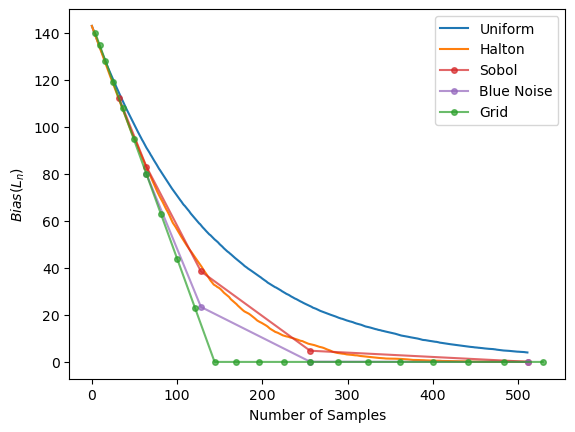

In [852]:
x = np.arange(1000000)
grid_sizes = [int(size) for size in points_per_axis[0][:22]**2]
plt.plot(x[:2**9],144-uniform_mean_c[0,:][:2**9],label="Uniform",color="tab:blue")
plt.plot(x[:2**9],144-halton_mean_c[0,:][:2**9],label="Halton",color="tab:orange")
plt.plot(sample_sizes[:5],144-sobol_mean_c[0,:][:5],marker="o",color="tab:red",label="Sobol",markersize=4,alpha=0.7)
plt.plot(blue_noise_sample_sizes[:4],144-blue_noise_mean_c[0,:][:4],marker="o",
             color="tab:purple",label="Blue Noise",markersize=4,alpha=0.7)
plt.plot(grid_sizes,144-grid_counts_c[0][0][:22],
         alpha=0.7,color="tab:green",marker="o",label="Grid",markersize=4)
plt.xlabel("Number of Samples")
plt.ylabel(r"$Bias(L_n)$")
plt.legend()

4D:

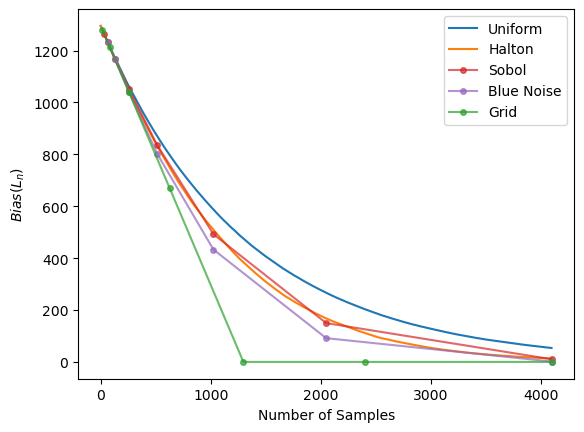

In [853]:
x = np.arange(1000000)
grid_sizes = [int(size) for size in points_per_axis[2]**4][:-6]
plt.plot(x[:2**12],1296-uniform_mean_c[2,:][:2**12],label="Uniform")
plt.plot(x[:2**12],1296-halton_mean_c[2,:][:2**12],label="Halton",color="tab:orange")
plt.plot(sample_sizes[:8],1296-sobol_mean_c[2,:][:8],marker="o",color="tab:red",label="Sobol",markersize=4,alpha=0.7)
plt.plot(blue_noise_sample_sizes[:7],1296-blue_noise_mean_c[2,:][:7],marker="o",
             color="tab:purple",label="Blue Noise",markersize=4,alpha=0.7)
plt.plot(grid_sizes,1296-grid_counts_c[2][0][:-6],color="tab:green",alpha=0.7,label="Grid",marker="o",markersize=4)
plt.xlabel("Number of Samples")
plt.ylabel(r"$Bias(L_n)$")
plt.legend()

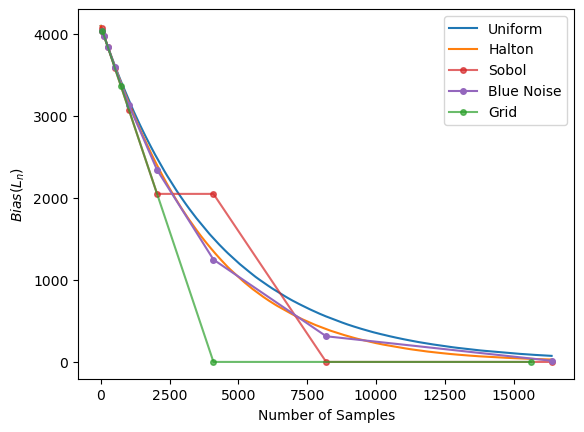

In [854]:
x = np.arange(1000000)
grid_sizes = [int(size) for size in points_per_axis[4]**6][:-1]
plt.plot(x[:2**14],4096-uniform_mean_c[4,:][:2**14],label="Uniform")
plt.plot(x[:2**14],4096-halton_mean_c[4,:][:2**14],label="Halton")
plt.plot(sample_sizes[:10],4096-sobol_mean_c[4,:][:10],marker="o",color="tab:red",label="Sobol",markersize=4,alpha=0.7)
plt.plot(blue_noise_sample_sizes[:9],4096-blue_noise_mean_c[4,:][:9],marker="o",
             color="tab:purple",label="Blue Noise",markersize=4)
plt.plot(grid_sizes,4096-grid_counts_c[4][0][:-1],alpha=0.7,color="tab:green",label="Grid",marker="o",markersize=4)
plt.xlabel("Number of Samples")
plt.ylabel(r"$Bias(L_n)$")
plt.legend()

8D:

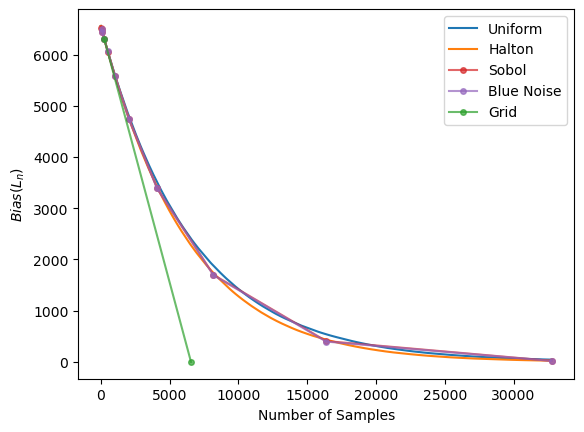

In [855]:
x = np.arange(1000000)
grid_sizes = [int(size) for size in points_per_axis[6]**8]
plt.plot(x[:2**15],6561-uniform_mean_c[6,:][:2**15],label="Uniform")
plt.plot(x[:2**15],6561-halton_mean_c[6,:][:2**15],label="Halton",color="tab:orange")
plt.plot(sample_sizes[:11],6561-sobol_mean_c[6,:][:11],marker="o",color="tab:red",label="Sobol",markersize=4,alpha=0.7)
plt.plot(blue_noise_sample_sizes[:10],6561-blue_noise_mean_c[6,:][:10],marker="o",
             color="tab:purple",label="Blue Noise",markersize=4,alpha=0.7)
plt.plot(grid_sizes, 6561-grid_counts_c[6][0],alpha=0.7,color="tab:green",label="Grid",marker="o",markersize=4)
plt.xlabel("Number of Samples")
plt.ylabel(r"$Bias(L_n)$")
plt.legend()

Standard deviation graphs:

2D:

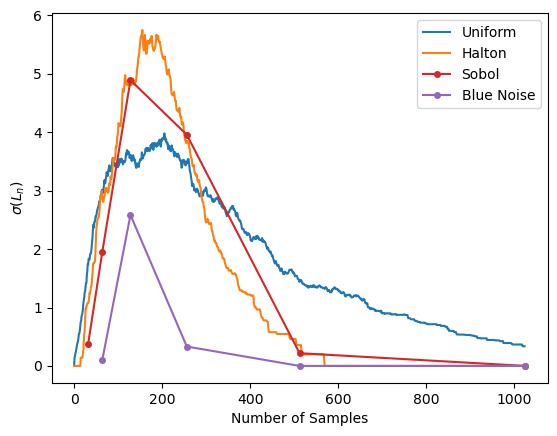

In [856]:
x = np.arange(1000000)
plt.plot(x[:2**10],np.sqrt(uniform_variances_c[0,:][:2**10]),color="tab:blue",label="Uniform")
plt.plot(x[:2**10],np.sqrt(halton_variances_c[0,:][:2**10]),label="Halton",color="tab:orange")
plt.plot(sample_sizes[:6],np.sqrt(sobol_variances_c[0,:][:6]),marker="o",color="tab:red",label="Sobol",markersize=4)
plt.plot(blue_noise_sample_sizes[:5],np.sqrt(blue_noise_variances_c[0,:][:5]),marker="o",
             color="tab:purple",label="Blue Noise",markersize=4)
plt.xlabel("Number of Samples")
plt.ylabel(r"$\sigma(L_n)$")
plt.legend()

4D:

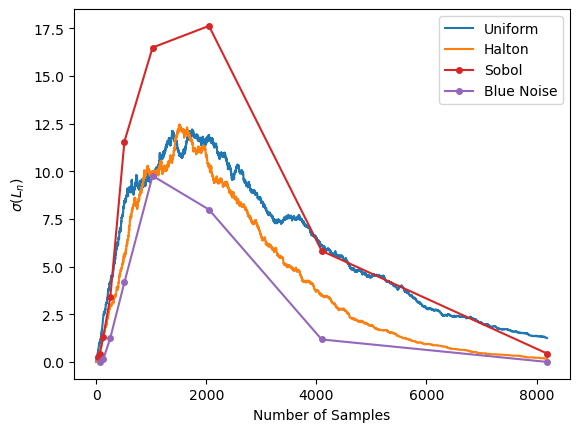

In [848]:
x = np.arange(1000000)
plt.plot(x[:2**13],np.sqrt(uniform_variances_c[2,:][:2**13]),color="tab:blue",label="Uniform")
plt.plot(x[:2**13],np.sqrt(halton_variances_c[2,:][:2**13]),label="Halton",color="tab:orange")
plt.plot(sample_sizes[:9],np.sqrt(sobol_variances_c[2,:][:9]),marker="o",color="tab:red",label="Sobol",markersize=4)
plt.plot(blue_noise_sample_sizes[:8],np.sqrt(blue_noise_variances_c[2,:][:8]),marker="o",
             color="tab:purple",label="Blue Noise",markersize=4)
plt.xlabel("Number of Samples")
plt.ylabel(r"$\sigma(L_n)$")
plt.legend()

6D:

In [643]:
sample_sizes = [2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]

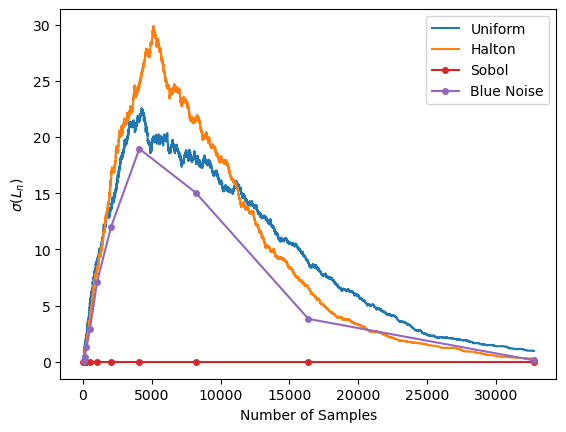

In [850]:
x = np.arange(1000000)
plt.plot(x[:2**15],np.sqrt(uniform_variances_c[4,:][:2**15]),color="tab:blue",label="Uniform")
plt.plot(x[:2**15],np.sqrt(halton_variances_c[4,:][:2**15]),label="Halton",color="tab:orange")
plt.plot(sample_sizes[:11],np.sqrt(sobol_variances_c[4,:][:11]),marker="o",color="tab:red",label="Sobol",markersize=4)
plt.plot(blue_noise_sample_sizes[:10],np.sqrt(blue_noise_variances_c[4,:][:10]),marker="o",
             color="tab:purple",label="Blue Noise",markersize=4)
plt.xlabel("Number of Samples")
plt.ylabel(r"$\sigma(L_n)$")
plt.legend()

8D:

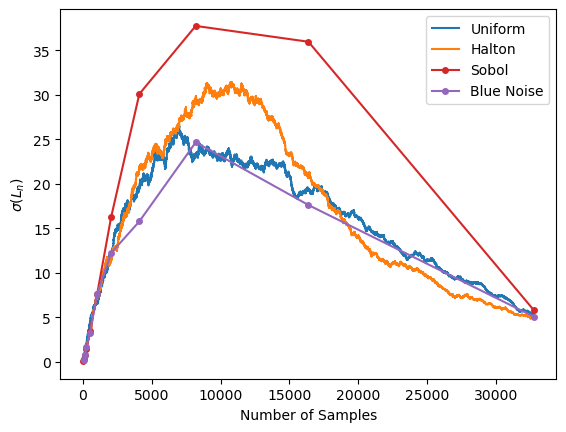

In [851]:
x = np.arange(1000000)
plt.plot(x[:2**15],np.sqrt(uniform_variances_c[6,:][:2**15]),color="tab:blue",label="Uniform")
plt.plot(x[:2**15],np.sqrt(halton_variances_c[6,:][:2**15]),label="Halton",color="tab:orange")
plt.plot(sample_sizes[:11],np.sqrt(sobol_variances_c[6,:][:11]),marker="o",color="tab:red",label="Sobol",markersize=4)
plt.plot(blue_noise_sample_sizes[:10],np.sqrt(blue_noise_variances_c[6,:][:10]),marker="o",
             color="tab:purple",label="Blue Noise",markersize=4)
plt.xlabel("Number of Samples")
plt.ylabel(r"$\sigma(L_n)$")
plt.legend()

Visualise what the samples look like in different dimensions:

In [595]:
hidden_neurons = 24
runs = 100
all_dimensions = [8]

# Load point sets and get them into the right format
path = '/Users/gautamchauhan/Desktop/MSc Project Code/blue_noise_points_100_runs'
lower_bound = 0
upper_bound = 1

blue_noise_sets = load_blue_noise_points(path,lower_bound,upper_bound)

blue_noise_counts_experimental = np.empty((max(all_dimensions),runs,len(blue_noise_sets[0])))

for dimensions in all_dimensions:

    # Pick out the sample points corresponding to the dimension
    sample_points = blue_noise_sets[dimensions-2]

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts,samples_by_region = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="offline",return_samples=True)
    unique_counts = unique_counts.detach().numpy()
    blue_noise_counts_experimental[dimensions-2,:,:] = unique_counts

In [593]:
print(len(samples_by_region.keys()))

3004


2D looks like:

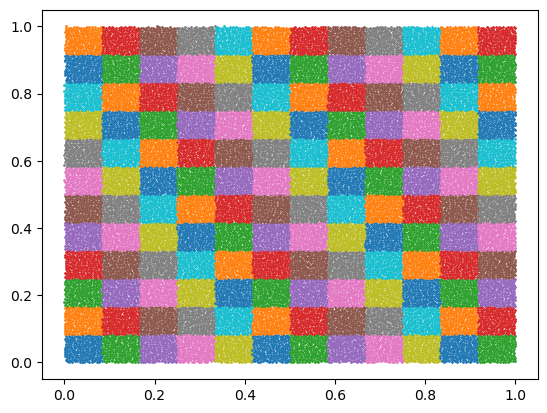

In [591]:
for key in samples_by_region:
    plt.scatter(samples_by_region[key][:,0],samples_by_region[key][:,1],s=1)

4D looks like:

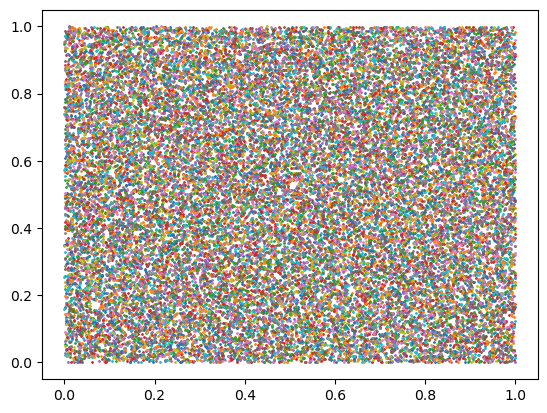

In [588]:
for key in samples_by_region:
    plt.scatter(samples_by_region[key][:,0],samples_by_region[key][:,1],s=1)

#### Formal Experiment Function

In [936]:
def experiment_3(sample_points,hidden_neurons,dimensions,runs=100,mode="online",return_samples=False):
    """Experiment for region counting using Montufar hypercubes example
    Args:
        sample_points: the sampling points used to count the regions - either numpy array (online counting) or list of arrays (offline)
        hidden_neurons: the number of neurons in the single hidden layer
        dimensions: the number of input dimensions
        runs: the number of times to rerun the experiment with different independent samples
        mode: whether to use the online/offline version of the region counting function
              online is used for BPP/Halton and offline for Sobol/Blue Noise
    Returns:
        unique_counts: 2D array of number of regions found after each number of samples for the different runs
    """

    p = int(np.floor(hidden_neurons/dimensions))
    
    # Set the network weights using p and dimension
    custom_weights = []
    for i in range(dimensions):
        segment_weights = [0 for i in range(dimensions)]
        segment_weights[i] = 1
        custom_weights += [segment_weights for _ in range(p)]
    custom_weights = [torch.tensor(custom_weights)]

    # Set the network biases so that we have a repeating pattern of small and large regions
    def generate_sequence(p):
        sequence = [0]
        for i in range(1,p):
            if i%2 == 1:
                # For every group of 2, make the first region 3 times bigger than the other in each axis
                value = -i/p - 1/(2*p)
            else:
                value = -i/p
            sequence.append(value)
        return sequence

    sequence = generate_sequence(p)
    print(len(sequence))
    print(sequence)
    custom_biases = [torch.tensor(np.tile(sequence, dimensions))]
        
    # custom_biases = [torch.tensor(np.tile([-np.sqrt(i)/p for i in range(p)], dimensions))]

    # Set up neural network - number of hidden neurons is p*n0 rather than hidden_neurons because the remainder neurons have weights
    # and biases set to 0 so they are essentially "dummy" neurons
    neurons_per_hidden = [p*dimensions]
    model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
    if mode == "online":
        unique_counts, samples_by_region = region_count_online(sample_points,model,return_samples=return_samples)
    else:
        unique_counts, samples_by_region = region_count_offline(sample_points,model,return_samples=return_samples)

    return unique_counts, samples_by_region

In [953]:
num_points = 1000000
all_dimensions = [2]
runs = 100
seed = 1
hidden_neurons = 22

iid_counts_experimental = np.empty((max(all_dimensions),runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region susing those point sets and assign to the appropriate part of iid_counts
    unique_counts,samples_by_region_experimental = experiment_3(sample_points,hidden_neurons,dimensions,runs,mode="online",return_samples=True)
    unique_counts = unique_counts.detach().numpy()
    iid_counts_experimental[dimensions-2,:,:] = unique_counts

11
[0, -0.13636363636363635, -0.18181818181818182, -0.3181818181818182, -0.36363636363636365, -0.5, -0.5454545454545454, -0.6818181818181818, -0.7272727272727273, -0.8636363636363636, -0.9090909090909091]


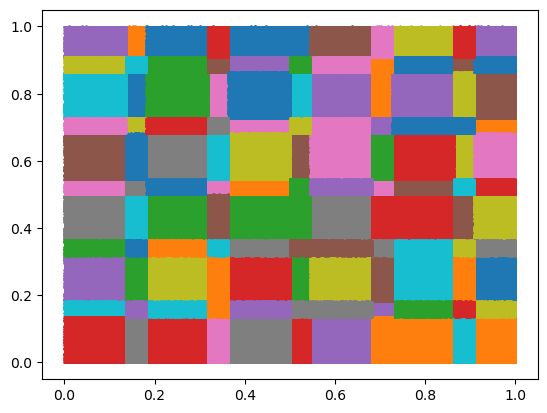

In [954]:
for key in samples_by_region_experimental:
    plt.scatter(samples_by_region_experimental[key][:,0],samples_by_region_experimental[key][:,1],s=1)

In [955]:
print(iid_counts_experimental)

[[[  1.   2.   3. ... 121. 121. 121.]
  [  1.   2.   3. ... 121. 121. 121.]
  [  1.   2.   3. ... 121. 121. 121.]
  ...
  [  1.   2.   3. ... 121. 121. 121.]
  [  1.   2.   3. ... 121. 121. 121.]
  [  1.   2.   3. ... 121. 121. 121.]]

 [[  0.   0.   0. ...   0.   0.   0.]
  [  0.   0.   0. ...   0.   0.   0.]
  [  0.   0.   0. ...   0.   0.   0.]
  ...
  [  0.   0.   0. ...   0.   0.   0.]
  [  0.   0.   0. ...   0.   0.   0.]
  [  0.   0.   0. ...   0.   0.   0.]]]


In [940]:
uniform_mean_experimental = np.mean(iid_counts_experimental[0],axis=0)

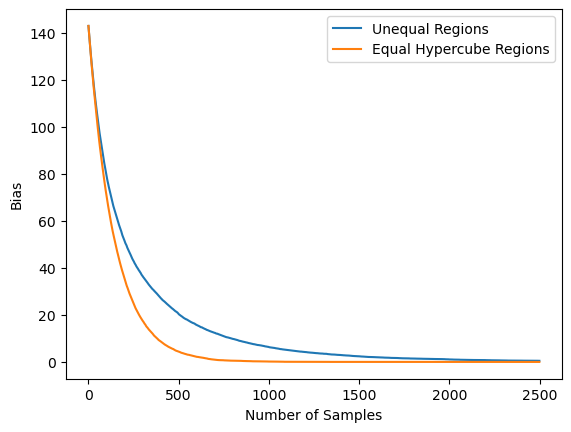

In [941]:
x = np.arange(2500)
plt.plot(x,144-uniform_mean_experimental[:2500],label="Unequal Regions")
plt.plot(x,144-uniform_mean_c[0,:2500],label="Equal Hypercube Regions")
plt.xlabel("Number of Samples")
plt.ylabel("Bias")
plt.legend()

In [956]:
volume_fractions = []
for key in samples_by_region_experimental.keys():
    count = len(samples_by_region_experimental[key])
    volume_fractions.append(count)

(array([25.,  0.,  0.,  0.,  0.,  0., 10.,  0.,  0.,  0.,  0.,  0., 50.,
         0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  9.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 15., 10.]),
 array([ 1946. ,  2286.4,  2626.8,  2967.2,  3307.6,  3648. ,  3988.4,
         4328.8,  4669.2,  5009.6,  5350. ,  5690.4,  6030.8,  6371.2,
         6711.6,  7052. ,  7392.4,  7732.8,  8073.2,  8413.6,  8754. ,
         9094.4,  9434.8,  9775.2, 10115.6, 10456. , 10796.4, 11136.8,
        11477.2, 11817.6, 12158. , 12498.4, 12838.8, 13179.2, 13519.6,
        13860. , 14200.4, 14540.8, 14881.2, 15221.6, 15562. , 15902.4,
        16242.8, 16583.2, 16923.6, 17264. , 17604.4, 17944.8, 18285.2,
        18625.6, 18966. ]),
 <BarContainer object of 50 artists>)

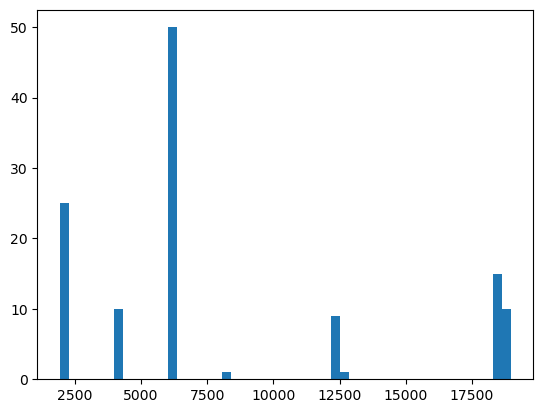

In [957]:
regions = np.arange(144)
plt.hist(volume_fractions,bins=50)

#### Save Experiment Data:

In [62]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_2/iid_counts_b.npy',iid_counts)

In [63]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_2/halton_counts_b.npy',halton_counts_b)

In [410]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_2/iid_counts_c.npy',iid_counts_c)

In [411]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_2/halton_counts_c.npy',halton_counts_c)

In [412]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_2/sobol_counts_c.npy',sobol_counts_c)

In [625]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_2/blue_noise_counts_c.npy',blue_noise_counts_c)